# Análise Exploratória — E-Commerce Brasileiro (Olist)

## Objetivo
Entender o comportamento de preços, categorias e demanda no e-commerce brasileiro,
identificando padrões que suportam modelos preditivos de precificação.

## Fonte dos dados
[Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


## Carregamento dos Dados

In [2]:
# Caminhos dos arquivos
DATA_PATH = '../data/raw/'

# Carregando as tabelas principais
orders = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
order_items = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
products = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
payments = pd.read_csv(DATA_PATH + 'olist_order_payments_dataset.csv')
customers = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')
category_translation = pd.read_csv(DATA_PATH + 'product_category_name_translation.csv')

print(f"Orders:      {orders.shape}")
print(f"Order Items: {order_items.shape}")
print(f"Products:    {products.shape}")
print(f"Payments:    {payments.shape}")
print(f"Customers:   {customers.shape}")
print(f"Categorias:  {category_translation.shape}")

Orders:      (99441, 8)
Order Items: (112650, 7)
Products:    (32951, 9)
Payments:    (103886, 5)
Customers:   (99441, 5)
Categorias:  (71, 2)


## Visão Geral dos Dados

In [3]:
# Visão geral de cada tabela
dfs = {
    'Orders': orders,
    'Order Items': order_items,
    'Products': products,
    'Payments': payments,
    'Customers': customers
}

for nome, df in dfs.items():
    print(f"\n{'='*50}")
    print(f"{nome} — {df.shape[0]} linhas x {df.shape[1]} colunas")
    print(f"Nulos:\n{df.isnull().sum()[df.isnull().sum() > 0]}")


Orders — 99441 linhas x 8 colunas
Nulos:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

Order Items — 112650 linhas x 7 colunas
Nulos:
Series([], dtype: int64)

Products — 32951 linhas x 9 colunas
Nulos:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Payments — 103886 linhas x 5 colunas
Nulos:
Series([], dtype: int64)

Customers — 99441 linhas x 5 colunas
Nulos:
Series([], dtype: int64)


## Construção do Dataset de Precificação

In [4]:
# Join das tabelas principais
df = order_items.merge(products, on='product_id', how='left')
df = df.merge(category_translation, on='product_category_name', how='left')
df = df.merge(orders[['order_id', 'order_status', 'order_purchase_timestamp']], on='order_id', how='left')

# Apenas pedidos entregues
df = df[df['order_status'] == 'delivered']

# Tradução da categoria em português → inglês
df['categoria'] = df['product_category_name_english'].fillna('sem_categoria')

# Converter data
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['ano_mes'] = df['order_purchase_timestamp'].dt.to_period('M')

print(f"Dataset final: {df.shape}")
print(f"\nColunas: {df.columns.tolist()}")
print(f"\nPeríodo: {df['order_purchase_timestamp'].min()} até {df['order_purchase_timestamp'].max()}")

Dataset final: (110197, 20)

Colunas: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'order_status', 'order_purchase_timestamp', 'categoria', 'ano_mes']

Período: 2016-09-15 12:16:38 até 2018-08-29 15:00:37


## Análise de Preços

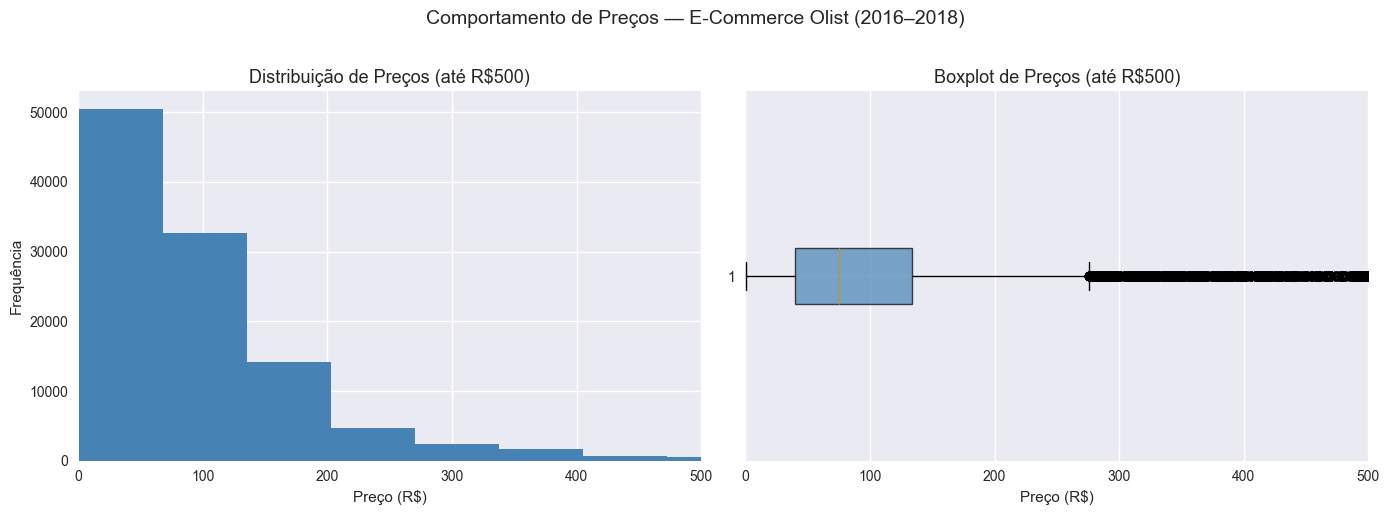

count    110197.00
mean        119.98
std         182.30
min           0.85
25%          39.90
50%          74.90
75%         134.17
max        6735.00
Name: price, dtype: float64

Produtos acima de R$500: 3090 (2.8%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição geral de preços
axes[0].hist(df['price'], bins=100, edgecolor='none', color='steelblue')
axes[0].set_xlim(0, 500)
axes[0].set_title('Distribuição de Preços (até R$500)', fontsize=13)
axes[0].set_xlabel('Preço (R$)')
axes[0].set_ylabel('Frequência')

# Boxplot por faixa
axes[1].boxplot(df['price'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_xlim(0, 500)
axes[1].set_title('Boxplot de Preços (até R$500)', fontsize=13)
axes[1].set_xlabel('Preço (R$)')

plt.suptitle('Comportamento de Preços — E-Commerce Olist (2016–2018)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../reports/01_distribuicao_precos.png', dpi=150, bbox_inches='tight')
plt.show()

# Estatísticas descritivas
print(df['price'].describe().round(2))
print(f"\nProdutos acima de R$500: {(df['price'] > 500).sum()} ({(df['price'] > 500).mean()*100:.1f}%)")

### Insights — Distribuição de Preços

- Preço médio R$119, mas mediana R$74 — distribuição assimétrica com cauda longa à direita
- 75% dos produtos custam até R$134 — mercado concentrado em itens acessíveis
- Apenas 2,8% dos produtos acima de R$500 — serão tratados como outliers no modelo preditivo

## Preço Médio por Categoria

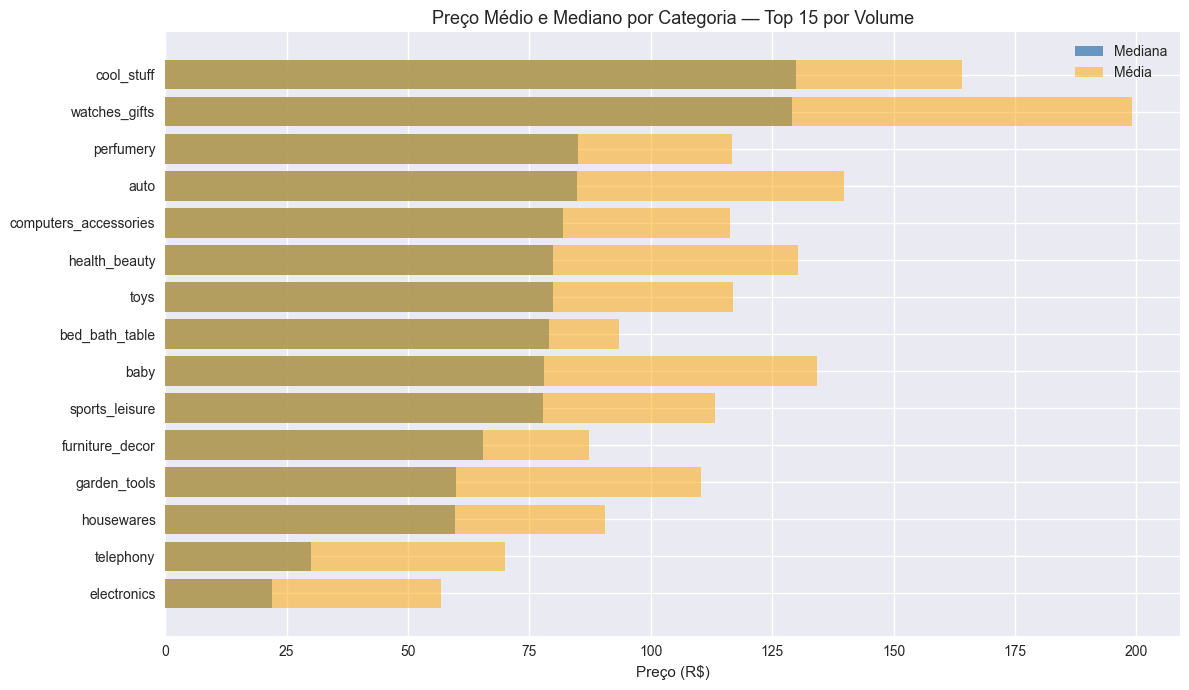

                         mean  median  count
categoria                                   
cool_stuff             164.12  129.90   3718
watches_gifts          199.04  128.99   5859
perfumery              116.81   84.99   3340
auto                   139.85   84.90   4140
computers_accessories  116.26   81.99   7644
toys                   116.94   79.90   4030
health_beauty          130.28   79.90   9465
bed_bath_table          93.44   79.05  10953
baby                   134.28   77.98   2982
sports_leisure         113.25   77.90   8431
furniture_decor         87.25   65.49   8160
garden_tools           110.24   59.90   4268
housewares              90.60   59.70   6795
telephony               69.95   29.99   4430
electronics             56.81   21.89   2729


In [7]:
# Top 15 categorias por volume
top_categorias = df['categoria'].value_counts().head(15).index

df_top = df[df['categoria'].isin(top_categorias)]

# Preço médio e mediano por categoria
cat_stats = df_top.groupby('categoria')['price'].agg(['mean', 'median', 'count']).round(2)
cat_stats = cat_stats.sort_values('median', ascending=True)

# Gráfico
fig, ax = plt.subplots(figsize=(12, 7))

x = range(len(cat_stats))
ax.barh(x, cat_stats['median'], color='steelblue', alpha=0.8, label='Mediana')
ax.barh(x, cat_stats['mean'], color='orange', alpha=0.5, label='Média')
ax.set_yticks(x)
ax.set_yticklabels(cat_stats.index)
ax.set_xlabel('Preço (R$)')
ax.set_title('Preço Médio e Mediano por Categoria — Top 15 por Volume', fontsize=13)
ax.legend()

plt.tight_layout()
plt.savefig('../reports/02_preco_por_categoria.png', dpi=150, bbox_inches='tight')
plt.show()

print(cat_stats.sort_values('median', ascending=False))

### Insights — Preço por Categoria

- **watches_gifts** tem a maior média (R$199) mas mediana R$129 — poucos produtos caros puxam a média para cima
- **electronics** e **telephony** têm as menores medianas (R$22 e R$30) — produtos de entrada dominam o volume
- A diferença entre média e mediana é maior em **cool_stuff** e **auto** — alta variabilidade de preços nessas categorias
- **bed_bath_table** é a categoria com maior volume (10.953 itens) com preço mediano equilibrado (R$79)

## Evolução de Vendas e Preços ao Longo do Tempo

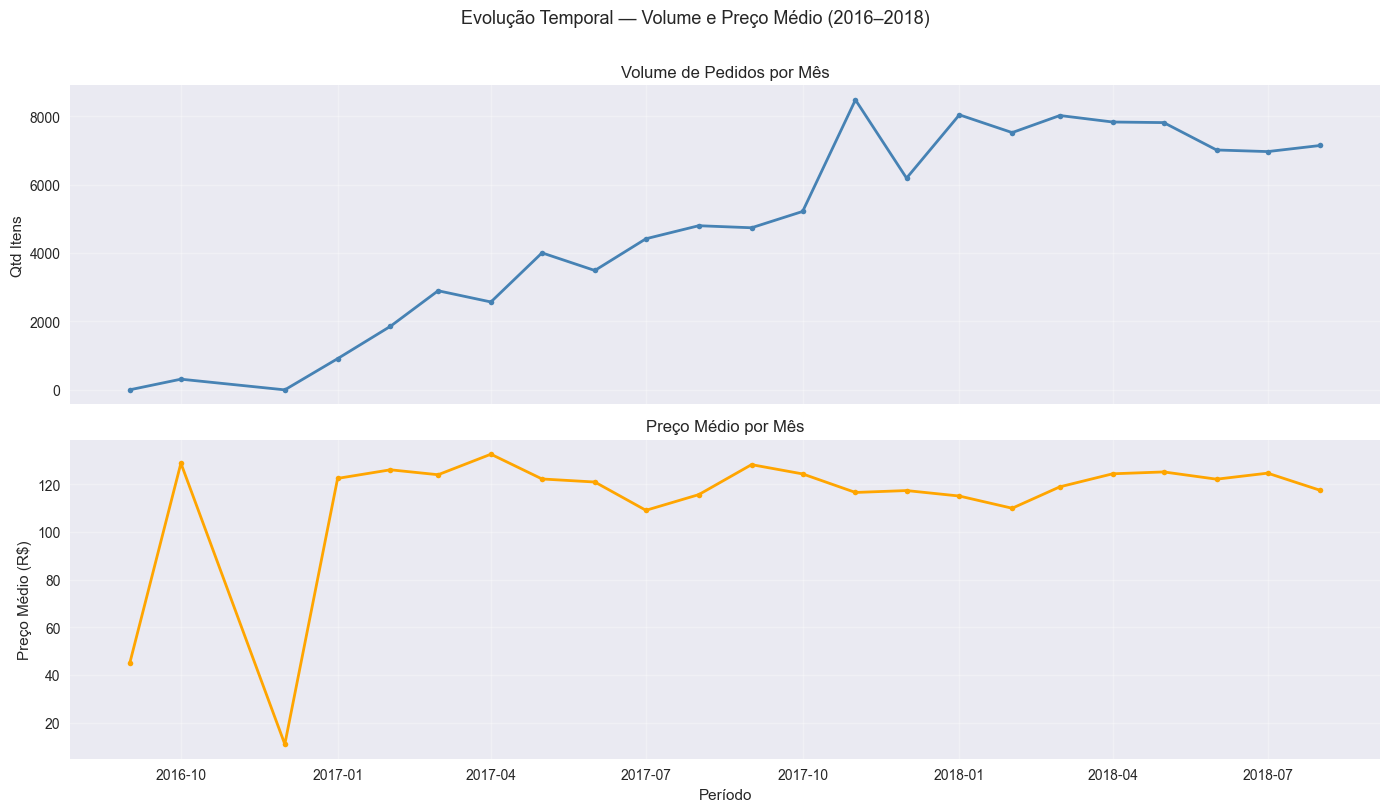

In [8]:
# Agrupa por mês
serie_temporal = df.groupby('ano_mes').agg(
    volume=('order_id', 'count'),
    preco_medio=('price', 'mean'),
    receita_total=('price', 'sum')
).reset_index()

serie_temporal['ano_mes_dt'] = serie_temporal['ano_mes'].dt.to_timestamp()

# Gráfico duplo
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Volume
axes[0].plot(serie_temporal['ano_mes_dt'], serie_temporal['volume'],
             color='steelblue', linewidth=2, marker='o', markersize=4)
axes[0].set_title('Volume de Pedidos por Mês', fontsize=12)
axes[0].set_ylabel('Qtd Itens')
axes[0].grid(True, alpha=0.3)

# Preço médio
axes[1].plot(serie_temporal['ano_mes_dt'], serie_temporal['preco_medio'],
             color='orange', linewidth=2, marker='o', markersize=4)
axes[1].set_title('Preço Médio por Mês', fontsize=12)
axes[1].set_ylabel('Preço Médio (R$)')
axes[1].set_xlabel('Período')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Evolução Temporal — Volume e Preço Médio (2016–2018)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../reports/03_serie_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

### Insights — Evolução Temporal

- **Crescimento expressivo de volume:** de ~100 itens/mês em set/2016 para ~8.000 em nov/2017 — crescimento de 80x em 14 meses
- **Pico em novembro/2017:** provavelmente Black Friday — sinal claro de sazonalidade
- **Preço médio estável:** após instabilidade nos primeiros meses (baixo volume, dados ruidosos), o preço médio se estabiliza entre R$110–130 de 2017 em diante
- **Os primeiros meses de 2016 são ruidosos** — volume muito baixo distorce médias, serão excluídos do modelo preditivo

## Relação entre Preço e Frete

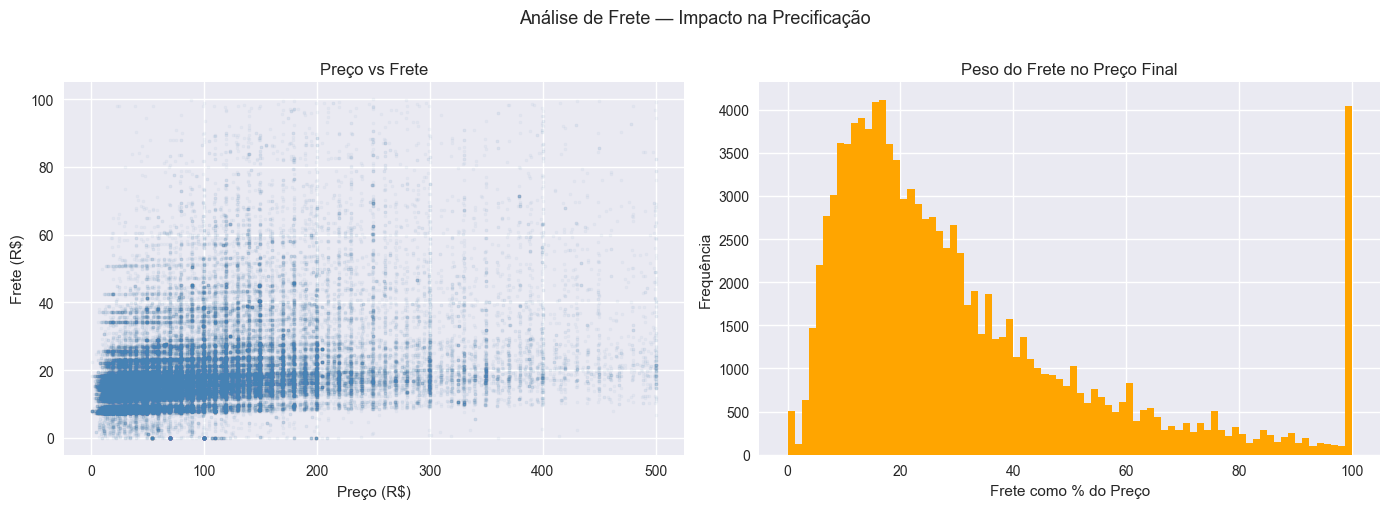

Frete médio: R$19.95
Frete mediano: R$16.26
Frete médio como % do preço: 32.1%


In [9]:
# Filtra outliers para visualização
df_plot = df[(df['price'] <= 500) & (df['freight_value'] <= 100)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter preço x frete
axes[0].scatter(df_plot['price'], df_plot['freight_value'],
                alpha=0.05, color='steelblue', s=5)
axes[0].set_xlabel('Preço (R$)')
axes[0].set_ylabel('Frete (R$)')
axes[0].set_title('Preço vs Frete')

# Frete como % do preço
df_plot2 = df_plot.copy()
df_plot2['frete_pct'] = df_plot2['freight_value'] / df_plot2['price'] * 100
df_plot2['frete_pct'] = df_plot2['frete_pct'].clip(0, 100)

axes[1].hist(df_plot2['frete_pct'], bins=80, color='orange', edgecolor='none')
axes[1].set_xlabel('Frete como % do Preço')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Peso do Frete no Preço Final')

plt.suptitle('Análise de Frete — Impacto na Precificação', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../reports/04_frete_preco.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Frete médio: R${df['freight_value'].mean():.2f}")
print(f"Frete mediano: R${df['freight_value'].median():.2f}")
print(f"Frete médio como % do preço: {(df['freight_value']/df['price']).mean()*100:.1f}%")

### Insights — Frete e Precificação

- **Frete médio de R$19,95** representa **32% do preço médio** — impacto significativo na decisão de compra
- Frete mediano R$16,26 — distribuição concentrada entre R$10–30
- Produtos baratos têm frete proporcionalmente mais caro — frete pode inviabilizar vendas de itens abaixo de R$30
- **Frete será uma feature importante no modelo preditivo** — correlação com categoria e peso do produto